In [20]:
import matplotlib.pyplot as plt
from os import environ
'''environ["OMP_NUM_THREADS"] = "1"
environ["OPENBLAS_NUM_THREADS"] = "1"
environ["MKL_NUM_THREADS"] = "1"
environ["VECLIB_MAXIMUM_THREADS"] = "1"
environ["NUMEXPR_NUM_THREADS"] = "1"'''
import numpy as np
import math
import multiprocessing
from multiprocessing import Pool
import csv
from numpy import linalg as la
#from scipy.stats import kde
#from scipy.fftpack import fft, ifft
#from IPython import get_ipython;   
#from itertools import repeat, izip
#get_ipython().magic('reset -sf')
#plt.close('all')

n = 1000
sigma = 0.2
mu = 0.7
gammax = 0.0
rmin = 3
rmax = 8
numr = 500
rvec = np.linspace(rmin, rmax, numr, endpoint=True)

numsample = 20
eff0 = 0.01


tmax = 100


numtrial = 1

kbound =1

if __name__ == '__main__':


    np.random.seed(123)

                
    #construct random interaction matrix
    axx = np.zeros((n,n))
    for i in range(0,n):
        for k in range(0,i):
            rand2 = np.random.uniform(0.0,1.0, 1)[0]
            rand3 = np.random.uniform(0.0,1.0, 1)[0]
            if rand2<0.5:
                axx[i][k] = -mu/n-sigma/np.sqrt(n)
            if rand2>0.5:
                axx[i][k] = -mu/n+sigma/np.sqrt(n)
            if rand3<0.5:
                axx[k][i] = -mu/n-sigma/np.sqrt(n)
            if rand3>0.5:
                axx[k][i] = -mu/n+sigma/np.sqrt(n)

    traj = np.zeros((numr, numsample))
    trajr = np.zeros((numr, numsample))

    rit = 0
    r = rvec[rit]
    print(r)
    x = np.ones(n)*(1.0-1.0/r)
    step = 0
    t = 0
    #Numerical integration
    while t <= tmax:

        x = r*x*(1.0 - (1.0-mu)*x + axx.dot(x))*np.heaviside(r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0)*np.heaviside(1.0-r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0) + (1.0-np.heaviside(1.0-r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0)) + 0.00001

        step = step +1
        t = t + 1

    xsort = np.sort(x)
    myind = n-1
    flag = 0
    while flag ==0 and myind>-1:
        if xsort[myind]<0.3:
            flag = 1
            myind = myind +1
        myind = myind -1
        if myind == 0:
            print("fail")

    refind = np.argmin(abs(x-xsort[int(myind)]))

    t= 0
    while t < numsample:
        traj[rit][int(t)] = np.copy(x[refind])
        trajr[rit][int(t)] = np.copy(r)
        x = r*x*(1.0 - (1.0-mu)*x + axx.dot(x))*np.heaviside(r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0)*np.heaviside(1.0-r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0) + (1.0-np.heaviside(1.0-r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0)) + 0.00001

        step = step +1
        t = t + 1

    for rit in range(1,numr):
        r = rvec[rit]
        print(r)
        x = np.ones(n)*(1.0-1.0/r)
        step = 0
        t = 0
        #Numerical integration
        while t <= tmax:

            x = r*x*(1.0 - (1.0-mu)*x + axx.dot(x))*np.heaviside(r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0)*np.heaviside(1.0-r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0) + (1.0-np.heaviside(1.0-r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0)) + 0.00001

            step = step +1
            t = t + 1
            
        t= 0
        while t < numsample:
            traj[rit][int(t)] = np.copy(x[refind])
            trajr[rit][int(t)] = np.copy(r)
            x = r*x*(1.0 - (1.0-mu)*x + axx.dot(x))*np.heaviside(r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0)*np.heaviside(1.0-r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0) + (1.0-np.heaviside(1.0-r*x*(1.0 - (1.0-mu)*x + axx.dot(x)),0.0)) + 0.00001

            step = step +1
            t = t + 1

    print("Simulation complete")





    
    #np.savetxt("lambdaversusr_sig0point2_n8000.csv", lambdavec, delimiter=",")
    #np.savetxt("rvecsim_sig0point2_n8000.csv", rvec, delimiter=",")

    








3.0
3.0100200400801604
3.0200400801603204
3.030060120240481
3.0400801603206413
3.0501002004008018
3.0601202404809618
3.070140280561122
3.0801603206412826
3.090180360721443
3.100200400801603
3.1102204408817635
3.120240480961924
3.130260521042084
3.1402805611222444
3.150300601202405
3.1603206412825653
3.1703406813627253
3.1803607214428857
3.190380761523046
3.200400801603206
3.2104208416833666
3.220440881763527
3.2304609218436875
3.2404809619238475
3.250501002004008
3.2605210420841684
3.270541082164329
3.280561122244489
3.2905811623246493
3.3006012024048097
3.31062124248497
3.32064128256513
3.3306613226452906
3.340681362725451
3.350701402805611
3.3607214428857715
3.370741482965932
3.3807615230460923
3.3907815631262523
3.400801603206413
3.4108216432865732
3.420841683366733
3.4308617234468937
3.440881763527054
3.4509018036072145
3.4609218436873745
3.470941883767535
3.4809619238476954
3.490981963927856
3.501002004008016
3.5110220440881763
3.5210420841683367
3.531062124248497
3.54108216432865

C:\Users\jwb96\AppData\Local\Temp\ipykernel_35420\2882110166.py:70: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


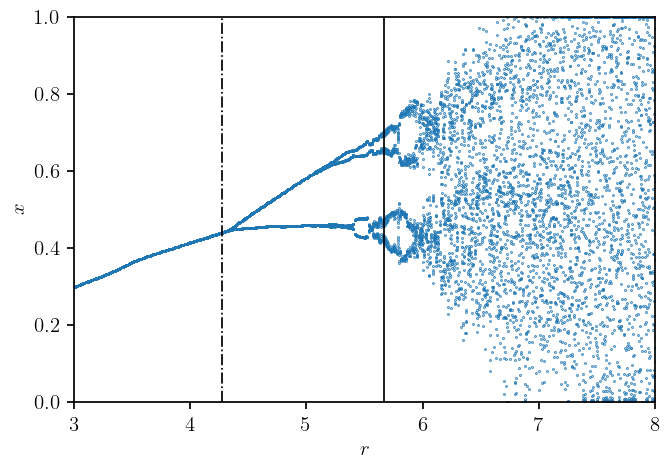

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import math
import multiprocessing
from multiprocessing import Pool
import csv
from numpy import linalg as la
#from scipy.stats import kde
#from itertools import repeat, izip
#from IPython import get_ipython;
#get_ipython().magic('reset -sf')
#plt.close('all')






eff0 = 0.001
effinf = 10.0**5


if __name__ == '__main__':

	
	#Plotting

	SIZE = 15

	plt.rc('font', size=SIZE)          # controls default text sizes
	plt.rc('axes', titlesize=SIZE)     # fontsize of the axes title
	plt.rc('axes', labelsize=SIZE)    # fontsize of the x and y labels
	plt.rc('xtick', labelsize=SIZE)    # fontsize of the tick labels
	plt.rc('ytick', labelsize=SIZE)    # fontsize of the tick labels
	plt.rc('legend', fontsize=SIZE-5)    # legend fontsize
	plt.rc('text', usetex=True)
	plt.rcParams['axes.linewidth'] = 1.25
	plt.rcParams['legend.loc'] = 'best'

	edgewidth = 1.5
	lwidth = 1.25
	size = 7.5
	tickwidth = 1.25
	ticklength = 5
	padness = 5
	fsize = 5

	trajflat = np.ndarray.flatten(traj)
	trajrflat = np.ndarray.flatten(trajr)

	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(trajrflat, trajflat, '.', markersize = (size -6.5), markeredgewidth = edgewidth)
	#ax1.plot(4.27523*np.ones(100), np.linspace(0,1,100,endpoint=True), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	#ax1.plot(5.66386*np.ones(100), np.linspace(0,1,100,endpoint=True), '-.', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	#ax1.plot(2.47447*np.ones(100), np.linspace(0,1,100,endpoint=True), '-.', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(4.27318*np.ones(100), np.linspace(0, 1, 100, endpoint= True), '-.', linewidth = lwidth, color = 'k',  label = r"Period-doubling onset")
	ax1.plot(5.66483*np.ones(100), np.linspace(0, 1, 100, endpoint= True), '-', linewidth = lwidth, color = 'k',  label = r"Oscillatory chaos onset")
	axes = plt.gca()
	axes.set_xlim([3.0,rmax])
	axes.set_ylim([0.0, 1.0])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$r$")
	ax1.set_ylabel(r"$x$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	plt.savefig("bifurcation_mu0point7_sigma0point2_n1000_v2.svg", format="svg")

	


	

In [8]:
print(lambdavec.shape)
print(sigmavec.shape)

(5, 21)
(50,)


In [11]:
print(sum(kvec**2))
print(sum(kvec)**2)

29339.0
9979281.0


In [15]:
gammavec

array([-0.8, -0.5, -0.2,  0.1,  0.4])

In [9]:
x = 1.2
np.heaviside(1-x, 0.0)

np.float64(0.0)

In [7]:
np.savetxt("lambdaversussigmavariousgamman1000numtrial10mu0point6imitation.csv", lambdavec, delimiter=",")
np.savetxt("mulversussigmavariousgamman1000numtrial10mu0point6imitation.csv", mulvec, delimiter=",")
#np.savetxt("gammalversussigmavariousgamman1000numtrial10.csv", gammalvec, delimiter=",")
np.savetxt("slversussigmavariousgamman1000numtrial10mu0point6imitation.csv", slvec, delimiter=",")
np.savetxt("s3lversussigmavariousgamman1000numtrial10mu0point6imitation.csv", s3lvec, delimiter=",")
np.savetxt("sigmavecimitation.csv", sigmavec, delimiter=",")

In [53]:
rlvecth

array([[-6.99790528e-04, -2.91533763e-03, -8.95305777e-03,
        -2.19577038e-02, -4.56424525e-02, -8.39982420e-02,
        -1.41277182e-01, -2.22214284e-01, -3.32393627e-01,
        -4.78704839e-01, -6.69886872e-01, -9.17190409e-01,
        -1.23521155e+00, -1.64296688e+00, -2.16529993e+00,
        -2.83473554e+00, -3.69393468e+00, -4.79895117e+00,
        -6.22355748e+00, -8.06499502e+00, -1.04516219e+01],
       [-8.59765613e-04, -2.30321004e-03, -5.28679624e-03,
        -1.06992952e-02, -1.95464610e-02, -3.28654128e-02,
        -5.16665195e-02, -7.69136068e-02, -1.09536372e-01,
        -1.50462721e-01, -2.00660275e-01, -2.61180535e-01,
        -3.33203060e-01, -4.18079514e-01, -5.17378869e-01,
        -6.32935620e-01, -7.66903175e-01, -9.21814728e-01,
        -1.10065408e+00, -1.30693912e+00, -1.54482108e+00],
       [-1.05222654e-03, -2.20462354e-03, -4.21083258e-03,
        -7.42731721e-03, -1.22359646e-02, -1.90135184e-02,
        -2.81065184e-02, -3.98159935e-02, -5.43923788e

In [3]:
import numpy as np

blah = np.array([0.1, 0.2, 0.01,0.5])
blahsort = np.sort(blah)
print(blahsort)
mymin = np.argmin(abs(blahsort-max(blahsort)/2))
blahsort[mymin]

[0.01 0.1  0.2  0.5 ]


np.float64(0.2)